# Training 1 Analysis

This notebook analyzes the initial training run, with no additional data cleaning, extracted under `training-outputs/outputs/benchmark` to evaluate performance of the algos on the environment and determine if additional preprocessing and hardening the training process is are needed.

## Scope

- Final run performance across seeds and algorithms
- Pilot sweep outcomes and winner margins
- Smoke run sanity checks
- Karpathy one-record overfit diagnostic
- Optional repro canary comparison
- Rule-based recommendation for next steps

In [1]:
from __future__ import annotations

import json
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("ggplot")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_ROOT = PROJECT_ROOT / "training-outputs" / "training_1" / "outputs" / "benchmark"

FINAL_DIR = DATA_ROOT / "final"
PILOT_DIR = DATA_ROOT / "pilot_sweeps"
SMOKE_DIR = DATA_ROOT / "smoke"
KARPATHY_DIR = DATA_ROOT / "karpathy"
REPRO_DIR = DATA_ROOT / "repro_canary"

print(f"Project root: {PROJECT_ROOT}")
print(f"Data root:    {DATA_ROOT}")
print(f"Exists:       {DATA_ROOT.exists()}")

Project root: /Users/tlam/4453-RL/firebot
Data root:    /Users/tlam/4453-RL/firebot/training-outputs/training_1/outputs/benchmark
Exists:       True


In [2]:
def load_json(path: Path):
    return json.loads(path.read_text())


def _iter_numbers(obj):
    if isinstance(obj, dict):
        for v in obj.values():
            yield from _iter_numbers(v)
    elif isinstance(obj, list):
        for v in obj:
            yield from _iter_numbers(v)
    elif isinstance(obj, (int, float)):
        yield float(obj)


def has_non_finite(obj) -> bool:
    for n in _iter_numbers(obj):
        if not math.isfinite(n):
            return True
    return False


def infer_seed_token(path: Path):
    stem = path.stem
    match = re.search(r"(\d+)$", stem)
    if match:
        return int(match.group(1))
    return stem


def extract_eval_seed_json(path: Path, stage: str = "final_eval_bundle", seed_override=None) -> list[dict]:
    payload = load_json(path)
    seed = seed_override if seed_override is not None else infer_seed_token(path)
    rows: list[dict] = []
    for agent, agent_payload in payload.get("results", {}).items():
        for split in ("train", "val", "family_holdout", "temporal_holdout_diagnostic"):
            split_obj = agent_payload.get(split)
            if not split_obj:
                continue
            aggregate = split_obj.get("aggregate", {})
            rows.append(
                {
                    "stage": stage,
                    "seed": seed,
                    "algo": agent,
                    "split": split,
                    "episodes": aggregate.get("episodes_per_seed"),
                    "mean_return": aggregate.get("mean_return"),
                    "asset_survival_rate": aggregate.get("asset_survival_rate"),
                    "containment_success_rate": aggregate.get("containment_success_rate"),
                    "mean_burned_area_fraction": aggregate.get("mean_burned_area_fraction"),
                    "mean_time_to_containment": aggregate.get("mean_time_to_containment"),
                    "mean_resource_efficiency": aggregate.get("mean_resource_efficiency"),
                    "wasted_deployment_rate": aggregate.get("wasted_deployment_rate"),
                    "mean_normalized_burn_ratio": aggregate.get("mean_normalized_burn_ratio"),
                }
            )
    return rows


def extract_final_eval_best(path: Path, stage: str) -> list[dict]:
    payload = load_json(path)
    rows: list[dict] = []
    algo = payload.get("algo")
    seed = payload.get("seed")
    for split, split_obj in payload.get("splits", {}).items():
        rows.append(
            {
                "stage": stage,
                "algo": algo,
                "seed": seed,
                "split": split,
                "episodes": split_obj.get("episodes"),
                "mean_return": split_obj.get("mean_return"),
                "asset_survival_rate": split_obj.get("asset_survival_rate"),
                "containment_success_rate": split_obj.get("containment_success_rate"),
                "mean_burned_area_fraction": split_obj.get("mean_burned_area_fraction"),
                "mean_time_to_containment": split_obj.get("mean_time_to_containment"),
                "mean_resource_efficiency": split_obj.get("mean_resource_efficiency"),
                "wasted_deployment_rate": split_obj.get("wasted_deployment_rate"),
                "mean_normalized_burn_ratio": split_obj.get("mean_normalized_burn_ratio"),
                "path": str(path),
            }
        )
    return rows


def extract_best_checkpoint(path: Path, stage: str) -> dict:
    payload = load_json(path)
    val = payload.get("val_metrics", {})
    return {
        "stage": stage,
        "algo": payload.get("algo"),
        "seed": payload.get("seed"),
        "selected_train_steps": payload.get("selected_train_steps"),
        "selection_metric": payload.get("selection_metric"),
        "tie_breaker": payload.get("tie_breaker"),
        "val_mean_return": val.get("mean_return"),
        "val_asset_survival_rate": val.get("asset_survival_rate"),
        "val_containment_success_rate": val.get("containment_success_rate"),
        "path": str(path),
    }


def extract_checkpoint_curve(path: Path, stage: str) -> list[dict]:
    payload = load_json(path)
    rows: list[dict] = []
    for entry in payload:
        algo = entry.get("algo")
        seed = entry.get("seed")
        step = entry.get("train_steps")
        selected = bool(entry.get("selected_for_best"))
        for split, split_obj in entry.get("splits", {}).items():
            rows.append(
                {
                    "stage": stage,
                    "algo": algo,
                    "seed": seed,
                    "split": split,
                    "train_steps": step,
                    "selected_for_best": selected,
                    "mean_return": split_obj.get("mean_return"),
                    "asset_survival_rate": split_obj.get("asset_survival_rate"),
                    "containment_success_rate": split_obj.get("containment_success_rate"),
                    "mean_burned_area_fraction": split_obj.get("mean_burned_area_fraction"),
                }
            )
    return rows


In [3]:
stages = {
    "final": FINAL_DIR,
    "pilot_sweeps": PILOT_DIR,
    "smoke": SMOKE_DIR,
    "karpathy": KARPATHY_DIR,
    "repro_canary": REPRO_DIR,
}

manifest_rows = []
for stage_name, stage_path in stages.items():
    count = len(list(stage_path.rglob("*.json"))) if stage_path.exists() else 0
    manifest_rows.append({"stage": stage_name, "exists": stage_path.exists(), "json_count": count})

manifest_df = pd.DataFrame(manifest_rows)
manifest_df

,stage,exists,json_count
0,final,True,65
1,pilot_sweeps,True,83
2,smoke,True,13
3,karpathy,True,15
4,repro_canary,True,12


## Final stage: seed-level and algorithm-level performance

In [4]:
final_eval_bundle_paths = sorted((FINAL_DIR / "eval").glob("seed_*.json"))
final_eval_best_paths = sorted(FINAL_DIR.glob("*/seed_*/final_eval_best.json"))
final_best_ckpt_paths = sorted(FINAL_DIR.glob("*/seed_*/best_checkpoint.json"))
final_ckpt_curve_paths = sorted(FINAL_DIR.glob("*/seed_*/checkpoint_metrics.json"))

final_bundle_rows = [row for p in final_eval_bundle_paths for row in extract_eval_seed_json(p)]
final_bundle_df = pd.DataFrame(final_bundle_rows)

final_best_rows = [row for p in final_eval_best_paths for row in extract_final_eval_best(p, stage="final")]
final_best_df = pd.DataFrame(final_best_rows)

final_best_ckpt_df = pd.DataFrame([extract_best_checkpoint(p, stage="final") for p in final_best_ckpt_paths])
final_curve_df = pd.DataFrame([row for p in final_ckpt_curve_paths for row in extract_checkpoint_curve(p, stage="final")])

print("final eval bundles:", len(final_eval_bundle_paths))
print("final best eval files:", len(final_eval_best_paths))
print("final best checkpoint files:", len(final_best_ckpt_paths))
print("final checkpoint curve files:", len(final_ckpt_curve_paths))

final eval bundles: 5
final best eval files: 15
final best checkpoint files: 15
final checkpoint curve files: 15


In [5]:
required_algos = {"ppo", "a2c", "dqn"}
required_seeds = {11, 22, 33, 44, 55}

present = final_best_df[["algo", "seed"]].drop_duplicates()
present_pairs = {(r.algo, int(r.seed)) for r in present.itertuples(index=False)}
missing_pairs = sorted([(a, s) for a in required_algos for s in required_seeds if (a, s) not in present_pairs])

non_finite_issues = []
for p in final_eval_best_paths + final_best_ckpt_paths + final_ckpt_curve_paths:
    payload = load_json(p)
    if has_non_finite(payload):
        non_finite_issues.append(str(p))

print("Missing algo/seed final_eval_best pairs:", missing_pairs)
print("Files with non-finite values:", len(non_finite_issues))
if non_finite_issues:
    print(pd.Series(non_finite_issues).head(20).to_string(index=False))

Missing algo/seed final_eval_best pairs: []
Files with non-finite values: 0


In [6]:
final_val = final_best_df[(final_best_df["split"] == "val") & (final_best_df["algo"].isin(["ppo", "a2c", "dqn"]))]

summary = (
    final_val.groupby("algo")[
        [
            "asset_survival_rate",
            "mean_return",
            "containment_success_rate",
            "mean_burned_area_fraction",
            "mean_resource_efficiency",
            "wasted_deployment_rate",
        ]
    ]
    .agg(["mean", "std", "min", "max"])
    .round(4)
)
summary

asset_survival_rate                     mean_return                          containment_success_rate                     mean_burned_area_fraction                          \
                    mean     std   min   max        mean      std     min     max                     mean     std   min   max                      mean     std     min     max   
algo                                                                                                                                                                               
a2c                0.706  0.0358  0.66  0.74     69.8614  24.4778  43.613  95.002                    0.208  0.0432  0.15  0.26                    0.2823  0.0119  0.2704  0.2996   
dqn                0.664  0.0378  0.60  0.70     45.4680  12.3947  29.112  55.197                    0.202  0.0363  0.16  0.24                    0.2893  0.0176  0.2701  0.3164   
ppo                0.668  0.0531  0.59  0.73     48.7396  21.1571  16.622  70.335                    0.216  0.0344  0.17  0.25                    0.2864  0.0193  0.2716  0.3164   

     mean_resource_efficiency                         wasted_deployment_rate                          
                         mean     std     min     max                   mean     std     min     max  
algo                                                                                                  
a2c                    0.6138  0.1289  0.4301  0.7680                 0.3862  0.1289  0.2320  0.5699  
dqn                    0.7778  0.0869  0.6627  0.8999                 0.2222  0.0869  0.1001  0.3373  
ppo                    0.6216  0.0935  0.4872  0.7400                 0.3784  0.0935  0.2600  0.5128

Text(0.5, 1.0, 'Final Val Asset Survival by Seed')

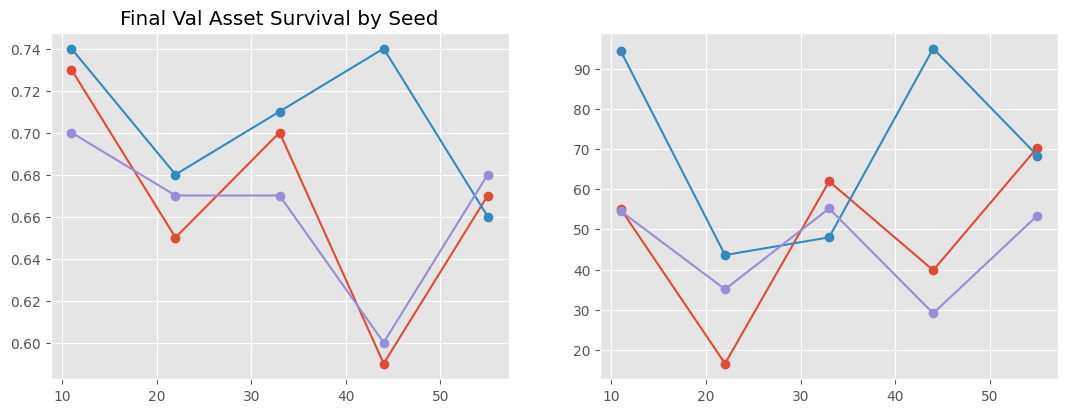

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for algo in ["ppo", "a2c", "dqn"]:
    sub = final_val[final_val["algo"] == algo].sort_values("seed")
    axes[0].plot(sub["seed"], sub["asset_survival_rate"], marker="o", label=algo)
    axes[1].plot(sub["seed"], sub["mean_return"], marker="o", label=algo)

axes[0].set_title("Final Val Asset Survival by Seed")

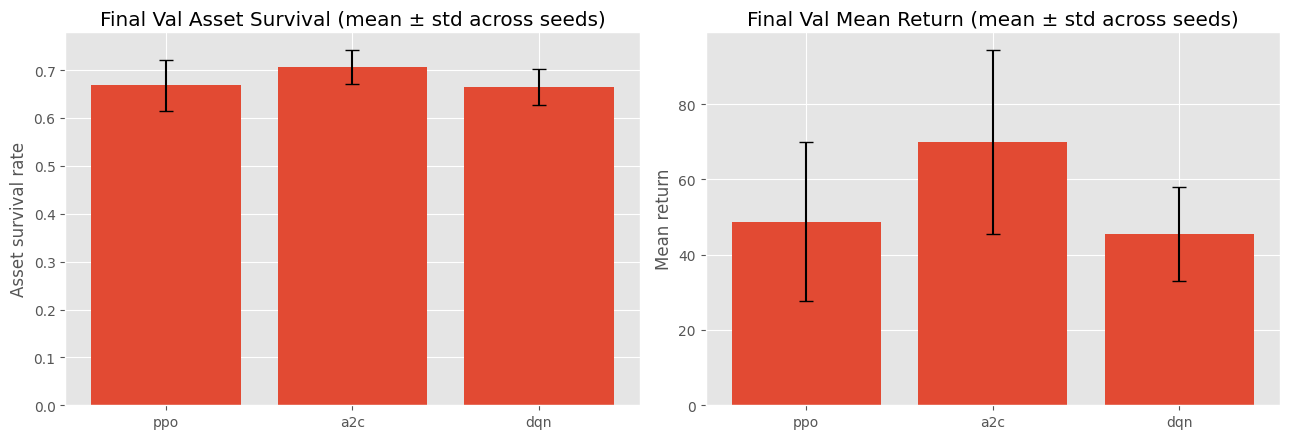

In [9]:
algos = ["ppo", "a2c", "dqn"]

# Compute mean + std across seeds
means_survival = []
stds_survival = []
means_return = []
stds_return = []

for algo in algos:
    sub = final_val[final_val["algo"] == algo]
    
    means_survival.append(sub["asset_survival_rate"].mean())
    stds_survival.append(sub["asset_survival_rate"].std())
    
    means_return.append(sub["mean_return"].mean())
    stds_return.append(sub["mean_return"].std())

x = np.arange(len(algos))
width = 0.6

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Asset survival
axes[0].bar(x, means_survival, yerr=stds_survival, capsize=5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(algos)
axes[0].set_title("Final Val Asset Survival (mean ± std across seeds)")
axes[0].set_ylabel("Asset survival rate")

# Mean return
axes[1].bar(x, means_return, yerr=stds_return, capsize=5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(algos)
axes[1].set_title("Final Val Mean Return (mean ± std across seeds)")
axes[1].set_ylabel("Mean return")

plt.tight_layout()
plt.show()

## Final checkpoint dynamics and selection audit

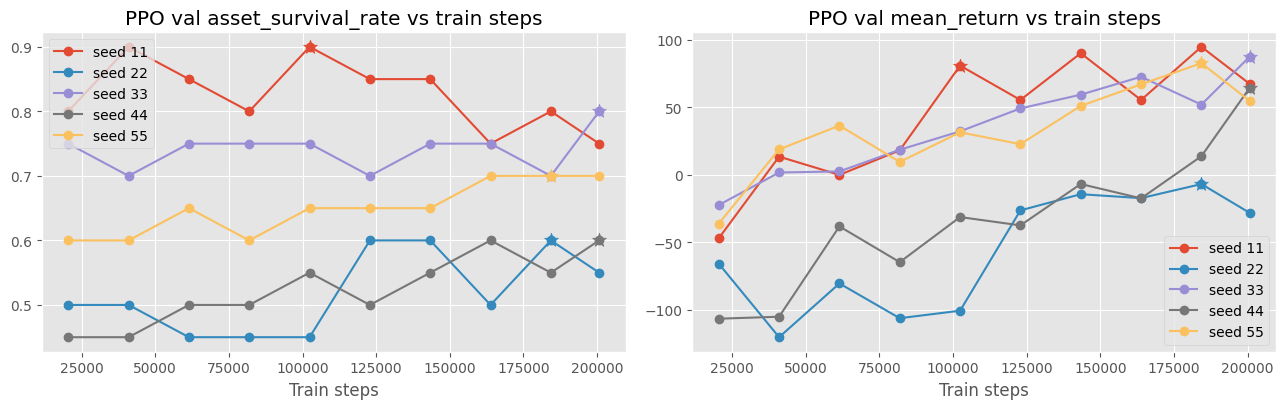

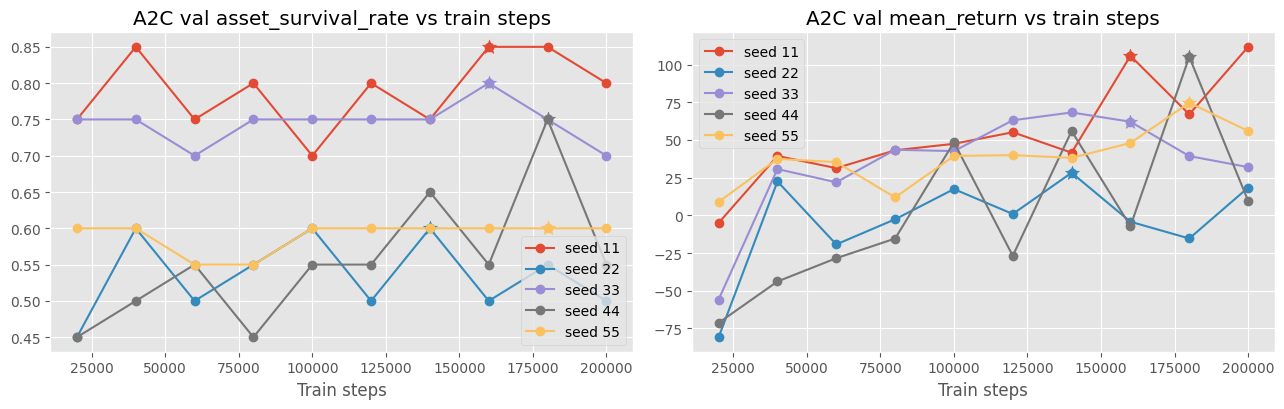

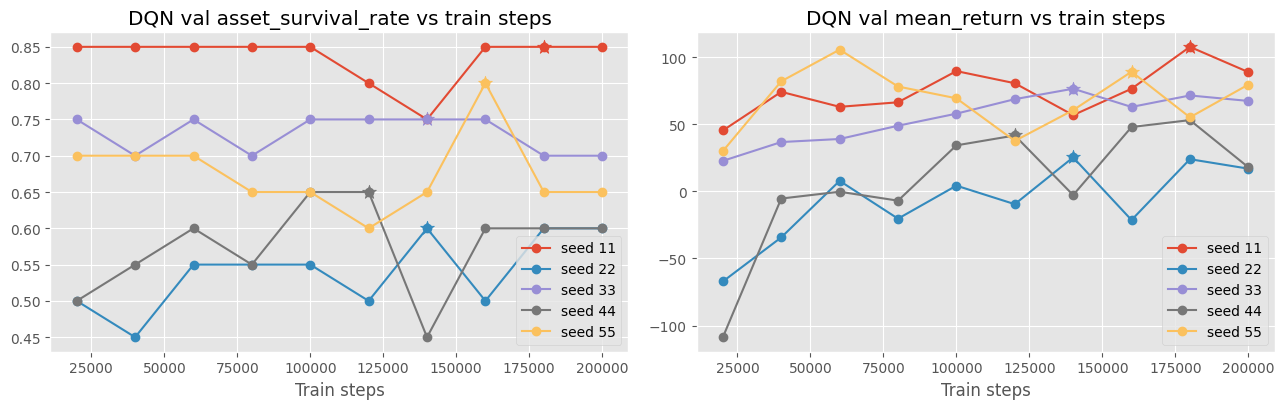

In [10]:
curve_val = final_curve_df[(final_curve_df["split"] == "val") & (final_curve_df["algo"].isin(["ppo", "a2c", "dqn"]))]

for algo in ["ppo", "a2c", "dqn"]:
    sub = curve_val[curve_val["algo"] == algo]
    if sub.empty:
        continue
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
    for seed in sorted(sub["seed"].unique()):
        ssub = sub[sub["seed"] == seed].sort_values("train_steps")
        axes[0].plot(ssub["train_steps"], ssub["asset_survival_rate"], marker="o", label=f"seed {seed}")
        axes[1].plot(ssub["train_steps"], ssub["mean_return"], marker="o", label=f"seed {seed}")

        best = ssub[ssub["selected_for_best"]]
        if not best.empty:
            axes[0].scatter(best["train_steps"], best["asset_survival_rate"], s=110, marker="*")
            axes[1].scatter(best["train_steps"], best["mean_return"], s=110, marker="*")

    axes[0].set_title(f"{algo.upper()} val asset_survival_rate vs train steps")
    axes[1].set_title(f"{algo.upper()} val mean_return vs train steps")
    for ax in axes:
        ax.set_xlabel("Train steps")
        ax.legend()
    plt.tight_layout()
    plt.show()

In [11]:
def selection_consistency(curve_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (algo, seed), sub in curve_df[curve_df["split"] == "val"].groupby(["algo", "seed"]):
        sub = sub.sort_values(["asset_survival_rate", "mean_return"], ascending=[False, False])
        if sub.empty:
            continue
        rule_pick = int(sub.iloc[0]["train_steps"])
        selected = sub[sub["selected_for_best"]]
        selected_step = int(selected.iloc[0]["train_steps"]) if not selected.empty else None
        rows.append(
            {
                "algo": algo,
                "seed": int(seed),
                "rule_pick_step": rule_pick,
                "selected_step": selected_step,
                "matches_rule": rule_pick == selected_step,
            }
        )
    return pd.DataFrame(rows).sort_values(["algo", "seed"])

selection_audit_df = selection_consistency(final_curve_df)
selection_audit_df

,algo,seed,rule_pick_step,selected_step,matches_rule
0,a2c,11,160000,160000,True
1,a2c,22,140000,140000,True
2,a2c,33,160000,160000,True
3,a2c,44,180000,180000,True
4,a2c,55,180000,180000,True
5,dqn,11,180000,180000,True
6,dqn,22,140000,140000,True
7,dqn,33,140000,140000,True
8,dqn,44,120000,120000,True
9,dqn,55,160000,160000,True


## Hyperparam Sweep Analysis

In [12]:
pilot_winner_paths = sorted(PILOT_DIR.glob("*/pilot_winner.json"))
pilot_winners = [load_json(p) for p in pilot_winner_paths]

pilot_rows = []
for pw in pilot_winners:
    algo = pw.get("algo")
    selected = pw.get("selected", {})
    cands = pw.get("candidates", [])
    cands_sorted = sorted(cands, key=lambda x: (x.get("asset_survival", -1), x.get("mean_return", -1e18)), reverse=True)
    margin = None
    if len(cands_sorted) >= 2:
        margin = float(cands_sorted[0].get("asset_survival", 0.0)) - float(cands_sorted[1].get("asset_survival", 0.0))
    pilot_rows.append(
        {
            "algo": algo,
            "selected_config": selected.get("config"),
            "selected_asset_survival": selected.get("asset_survival"),
            "selected_mean_return": selected.get("mean_return"),
            "runner_up_margin_asset_survival": margin,
            "candidate_count": len(cands),
        }
    )

pilot_summary_df = pd.DataFrame(pilot_rows).sort_values("algo")
pilot_summary_df

,algo,selected_config,selected_asset_survival,selected_mean_return,runner_up_margin_asset_survival,candidate_count
0,a2c,lr1e3_n5_ent001,0.85,39.370,0.05,6
1,dqn,lr1e4_ef03_eps01_tu1000_buf100k,0.85,74.280,0.00,8
2,ppo,lr5e4_n512_ent001,0.90,13.415,0.05,6


In [13]:
pilot_candidate_rows = []
for pw in pilot_winners:
    algo = pw.get("algo")
    for c in pw.get("candidates", []):
        pilot_candidate_rows.append({"algo": algo, **c})

pilot_candidates_df = pd.DataFrame(pilot_candidate_rows)
pilot_candidates_df

,algo,config,asset_survival,mean_return,containment,selected_checkpoint_step
0,a2c,lr1e3_n5_ent001,0.85,39.370,0.20,40000
1,a2c,lr7e4_n10_ent001,0.80,3.865,0.15,40000
2,a2c,lr7e4_n5_ent005,0.80,-9.760,0.20,20000
3,a2c,lr7e4_n20_ent001,0.80,-37.890,0.10,20000
4,a2c,lr3e4_n5_ent001,0.80,-98.585,0.10,20000
5,a2c,lr7e4_n5_ent002,0.75,34.710,0.20,40000
6,dqn,lr1e4_ef03_eps01_tu1000_buf100k,0.85,74.280,0.15,40000
7,dqn,lr5e5_ef02_eps005_tu1000_buf100k,0.85,60.870,0.10,20000
8,dqn,lr1e4_ef02_eps005_tu500_buf100k,0.85,48.230,0.25,20000
9,dqn,lr3e4_ef02_eps005_tu1000_buf100k,0.85,47.680,0.10,20000


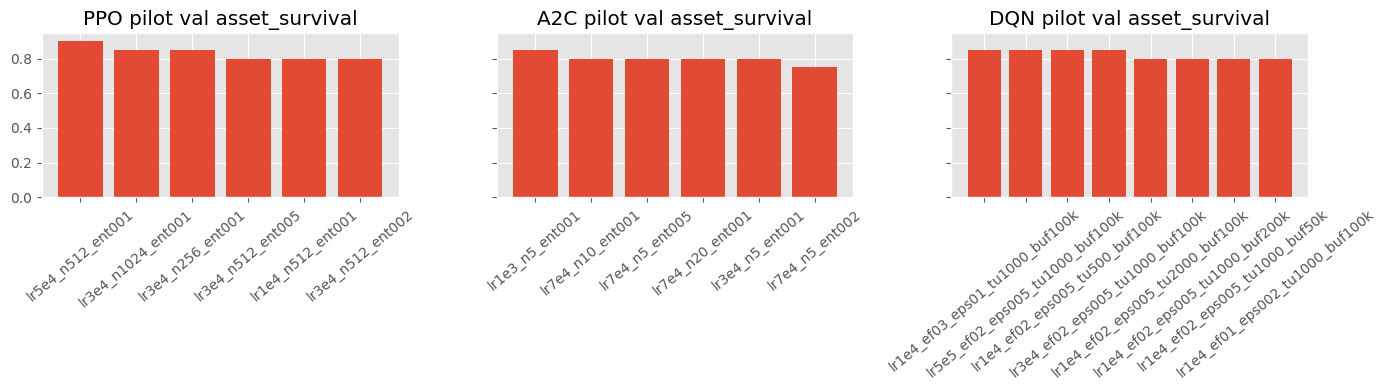

In [14]:
if not pilot_candidates_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    for i, algo in enumerate(["ppo", "a2c", "dqn"]):
        sub = pilot_candidates_df[pilot_candidates_df["algo"] == algo].sort_values("asset_survival", ascending=False)
        if sub.empty:
            axes[i].set_title(f"{algo.upper()} (no data)")
            continue
        axes[i].bar(sub["config"], sub["asset_survival"])
        axes[i].set_title(f"{algo.upper()} pilot val asset_survival")
        axes[i].tick_params(axis="x", rotation=40)
    plt.tight_layout()
    plt.show()

## Smoke run checks

In [15]:
smoke_eval_path = SMOKE_DIR / "eval_smoke.json"
smoke_rows = extract_eval_seed_json(smoke_eval_path, stage="smoke_eval_bundle", seed_override="smoke") if smoke_eval_path.exists() else []
smoke_df = pd.DataFrame(smoke_rows)
smoke_val = smoke_df[smoke_df["split"] == "val"].copy() if not smoke_df.empty else pd.DataFrame()

if not smoke_val.empty:
    smoke_summary = smoke_val[
        [
            "algo",
            "asset_survival_rate",
            "mean_return",
            "containment_success_rate",
            "mean_burned_area_fraction",
            "mean_resource_efficiency",
            "wasted_deployment_rate",
        ]
    ].sort_values(["asset_survival_rate", "mean_return"], ascending=[False, False])
    display(smoke_summary)
else:
    smoke_val

,algo,asset_survival_rate,mean_return,containment_success_rate,mean_burned_area_fraction,mean_resource_efficiency,wasted_deployment_rate
7,greedy,1.0,171.16,0.8,0.04704,1.000000,0.000000
5,dqn,1.0,54.54,0.0,0.36992,0.494737,0.505263
3,a2c,1.0,21.46,0.0,0.38240,1.000000,0.000000
1,ppo,1.0,-2.32,0.0,0.38240,0.000000,0.000000
9,random,0.8,-44.24,0.0,0.38112,0.213048,0.786952


## Overfit Check: Check if model overfits on a single record for architectural soundness 

In [16]:
karpathy_best_paths = sorted(KARPATHY_DIR.glob("*/seed_*/final_eval_best.json"))
karpathy_rows = [row for p in karpathy_best_paths for row in extract_final_eval_best(p, stage="karpathy")]
karpathy_df = pd.DataFrame(karpathy_rows)

karpathy_train = karpathy_df[(karpathy_df["split"] == "train") & (karpathy_df["algo"].isin(["ppo", "a2c", "dqn"]))]
karpathy_train[["algo", "mean_return", "asset_survival_rate", "containment_success_rate", "mean_burned_area_fraction"]].sort_values("algo")

,algo,mean_return,asset_survival_rate,containment_success_rate,mean_burned_area_fraction
0,a2c,133.27,1.00,0.25,0.11136
2,dqn,59.24,0.90,0.25,0.12496
4,ppo,26.16,0.95,0.20,0.12832


## Check if seeds working

In [17]:
repro_best_ckpt_paths = sorted(REPRO_DIR.glob("smoke/*/seed_*/best_checkpoint.json"))
repro_ckpt_df = pd.DataFrame([extract_best_checkpoint(p, stage="repro_smoke") for p in repro_best_ckpt_paths]) if repro_best_ckpt_paths else pd.DataFrame()

base_smoke_best_ckpt_paths = sorted(SMOKE_DIR.glob("*/seed_*/best_checkpoint.json"))
base_smoke_ckpt_df = pd.DataFrame([extract_best_checkpoint(p, stage="smoke") for p in base_smoke_best_ckpt_paths]) if base_smoke_best_ckpt_paths else pd.DataFrame()

if not repro_ckpt_df.empty and not base_smoke_ckpt_df.empty:
    compare_cols = ["algo", "seed", "selected_train_steps", "val_asset_survival_rate", "val_mean_return"]
    merged = base_smoke_ckpt_df[compare_cols].merge(
        repro_ckpt_df[compare_cols],
        on=["algo", "seed"],
        suffixes=("_smoke", "_repro"),
    )
    merged["step_match"] = merged["selected_train_steps_smoke"] == merged["selected_train_steps_repro"]
    merged["asset_survival_delta"] = merged["val_asset_survival_rate_repro"] - merged["val_asset_survival_rate_smoke"]
    merged["mean_return_delta"] = merged["val_mean_return_repro"] - merged["val_mean_return_smoke"]
    display(merged.sort_values(["algo", "seed"]))
else:
    print("No repro canary files found to compare.")

,algo,seed,selected_train_steps_smoke,val_asset_survival_rate_smoke,val_mean_return_smoke,selected_train_steps_repro,val_asset_survival_rate_repro,val_mean_return_repro,step_match,asset_survival_delta,mean_return_delta
0,a2c,11,20000,0.85,-0.935,20000,0.85,-0.935,True,0.0,0.0
1,dqn,11,20000,0.80,5.375,20000,0.80,5.375,True,0.0,0.0
2,ppo,11,20480,0.80,-37.890,20480,0.80,-37.890,True,0.0,0.0


## Decision table and recommended next steps

In [18]:
learned_algos = ["ppo", "a2c", "dqn"]

if "smoke_val" not in globals():
    smoke_eval_path = SMOKE_DIR / "eval_smoke.json"
    smoke_rows = extract_eval_seed_json(smoke_eval_path, stage="smoke_eval_bundle", seed_override="smoke") if smoke_eval_path.exists() else []
    smoke_df = pd.DataFrame(smoke_rows)
    smoke_val = smoke_df[smoke_df["split"] == "val"].copy() if not smoke_df.empty else pd.DataFrame()

final_val_core = final_val[
    [
        "algo",
        "seed",
        "asset_survival_rate",
        "mean_return",
        "containment_success_rate",
        "mean_burned_area_fraction",
    ]
].copy()

final_stats = final_val_core.groupby("algo").agg(
    val_mean_asset_survival=("asset_survival_rate", "mean"),
    std_across_seeds_asset_survival=("asset_survival_rate", "std"),
    val_mean_return=("mean_return", "mean"),
    std_across_seeds_return=("mean_return", "std"),
    val_mean_containment_success=("containment_success_rate", "mean"),
    std_across_seeds_containment_success=("containment_success_rate", "std"),
    val_mean_burned_area_fraction=("mean_burned_area_fraction", "mean"),
    std_across_seeds_burned_area_fraction=("mean_burned_area_fraction", "std"),
).reset_index()

smoke_val_agents = smoke_val[smoke_val["algo"].isin(learned_algos)] if not smoke_val.empty else pd.DataFrame()
random_smoke = smoke_val[smoke_val["algo"] == "random"]["asset_survival_rate"].mean() if not smoke_val.empty else np.nan

final_stats["smoke_beats_random_asset_survival"] = final_stats["algo"].map(
    {
        a: (
            float(smoke_val_agents[smoke_val_agents["algo"] == a]["asset_survival_rate"].mean()) > random_smoke
            if (not smoke_val_agents.empty and not np.isnan(random_smoke))
            else None
        )
        for a in learned_algos
    }
)

sel_ok = selection_audit_df.groupby("algo")["matches_rule"].all().to_dict() if not selection_audit_df.empty else {}
final_stats["selection_rule_consistent"] = final_stats["algo"].map(lambda a: sel_ok.get(a, None))

karpathy_ok_map = {}
if not karpathy_train.empty:
    for a in learned_algos:
        sub = karpathy_train[karpathy_train["algo"] == a]
        if sub.empty:
            karpathy_ok_map[a] = None
        else:
            karpathy_ok_map[a] = bool(float(sub["containment_success_rate"].mean()) > 0.0)

final_stats["karpathy_nonzero_containment"] = final_stats["algo"].map(lambda a: karpathy_ok_map.get(a, None))

final_stats = final_stats.sort_values("val_mean_asset_survival", ascending=False).round(4)
display(final_stats)

,algo,val_mean_asset_survival,std_across_seeds_asset_survival,val_mean_return,std_across_seeds_return,val_mean_containment_success,std_across_seeds_containment_success,val_mean_burned_area_fraction,std_across_seeds_burned_area_fraction,smoke_beats_random_asset_survival,selection_rule_consistent,karpathy_nonzero_containment
0,a2c,0.706,0.0358,69.8614,24.4778,0.208,0.0432,0.2823,0.0119,True,True,True
2,ppo,0.668,0.0531,48.7396,21.1571,0.216,0.0344,0.2864,0.0193,True,True,True
1,dqn,0.664,0.0378,45.4680,12.3947,0.202,0.0363,0.2893,0.0176,True,True,True


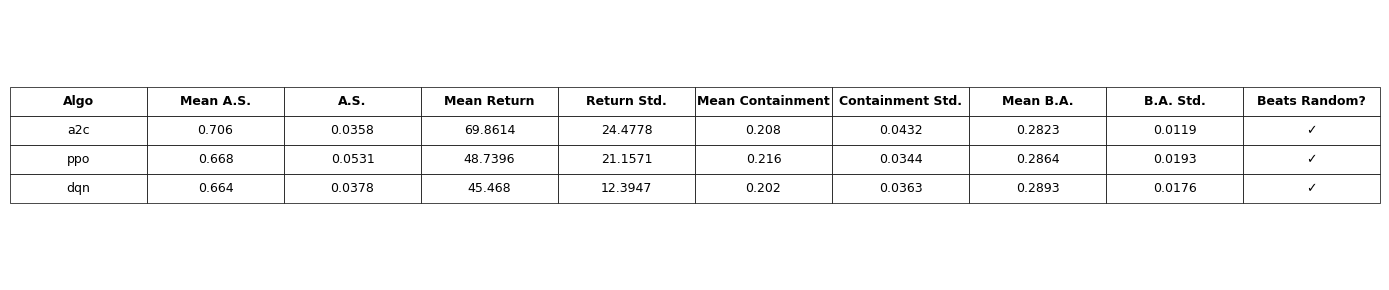

In [22]:
# Prepare display version
table_df = final_stats.copy()

# Optional: shorten column names for slides
table_df = table_df.rename(columns={
    "algo": "Algo",
    "val_mean_asset_survival": "Mean A.S.",
    "std_across_seeds_asset_survival": "A.S.",
    "val_mean_return": "Mean Return",
    "std_across_seeds_return": "Return Std.",
    "val_mean_containment_success": "Mean Containment",
    "std_across_seeds_containment_success": "Containment Std.",
    "val_mean_burned_area_fraction": "Mean B.A.",
    "std_across_seeds_burned_area_fraction": "B.A. Std.",
    "smoke_beats_random_asset_survival": "Beats Random?",
    "selection_rule_consistent": "Selection OK?",
    "karpathy_nonzero_containment": "Karpathy OK?"
})

table_df = table_df.drop(columns=["Selection OK?", "Karpathy OK?"])

# Convert booleans to checkmarks for nicer slides
table_df = table_df.replace({True: "✓", False: "✗"})

fig, ax = plt.subplots(figsize=(14, 3))
ax.axis('off')

table = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    loc='center',
    cellLoc='center'
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

# Bold header
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')

plt.tight_layout()

# Save for slides
plt.savefig("final_results_table.png", dpi=300, bbox_inches='tight')
plt.show()

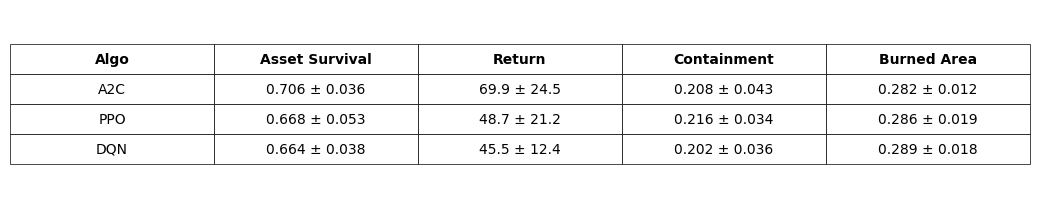

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

# Build compact slide table from final_stats
table_df = final_stats.copy()

# Keep only core benchmark columns
table_df = table_df[
    [
        "algo",
        "val_mean_asset_survival",
        "std_across_seeds_asset_survival",
        "val_mean_return",
        "std_across_seeds_return",
        "val_mean_containment_success",
        "std_across_seeds_containment_success",
        "val_mean_burned_area_fraction",
        "std_across_seeds_burned_area_fraction",
    ]
].copy()

# Format mean ± std into single columns
table_df["Asset Survival"] = table_df.apply(
    lambda r: f'{r["val_mean_asset_survival"]:.3f} ± {r["std_across_seeds_asset_survival"]:.3f}',
    axis=1
)
table_df["Return"] = table_df.apply(
    lambda r: f'{r["val_mean_return"]:.1f} ± {r["std_across_seeds_return"]:.1f}',
    axis=1
)
table_df["Containment"] = table_df.apply(
    lambda r: f'{r["val_mean_containment_success"]:.3f} ± {r["std_across_seeds_containment_success"]:.3f}',
    axis=1
)
table_df["Burned Area"] = table_df.apply(
    lambda r: f'{r["val_mean_burned_area_fraction"]:.3f} ± {r["std_across_seeds_burned_area_fraction"]:.3f}',
    axis=1
)

# Final compact table
table_df = table_df[
    ["algo", "Asset Survival", "Return", "Containment", "Burned Area"]
].rename(columns={"algo": "Algo"})

# Optional: uppercase algo names
table_df["Algo"] = table_df["Algo"].str.upper()

# Draw as image
fig, ax = plt.subplots(figsize=(10.5, 2.2))
ax.axis("off")

table = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    loc="center",
    cellLoc="center",
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")

plt.tight_layout()
plt.savefig("final_results_table_compact.png", dpi=300, bbox_inches="tight")
plt.show()